In [2]:
import numpy as np 

In [29]:
water1 = np.array([
    [ 0.000000,  0.000000,  0.000000],   
    [ 0.957200,  0.000000,  0.000000],   
    [-0.239987,  0.927297,  0.000000]    
])

water2 = np.array([
    [ 0.010000, -0.020000,  0.000000],  
    [ 0.980000,  0.050000,  0.020000],   
    [-0.260000,  0.900000, -0.030000]    
])

N_atoms = len(water1)


In [ ]:
def calculate_centroid(geometry,N_atoms):

    centroid = []
    x_sum = 0
    y_sum = 0 
    z_sum = 0 

    for row in geometry:
        x_sum = x_sum + row[0]
        y_sum = y_sum + row[1]
        z_sum = z_sum + row[2]

    x_mean = x_sum / N_atoms 
    y_mean = y_sum / N_atoms 
    z_mean = z_sum / N_atoms 

    centroid.append(x_mean)  
    centroid.append(y_mean)  
    centroid.append(z_mean)  


        
    return centroid 


def subtract_centroid(geometry,centroid):
    translated_geometry = []
    for row in geometry:
        translated_row = row - centroid

        translated_geometry.append(translated_row)
        
    translated_geometry = np.array(translated_geometry)
    return translated_geometry 

def calculate_cross_cov_matrix(geom1,geom2):
    for row in range(N_atoms):





In [ ]:
centroid_1 = calculate_centroid(water1,N_atoms)

translated_2 = subtract_centroid(water2,centroid_1)

In [28]:
print(water2)
print(translated_2)

[[ 0.01 -0.02  0.  ]
 [ 0.98  0.05  0.02]
 [-0.26  0.9  -0.03]]
[[-0.229071 -0.329099  0.      ]
 [ 0.740929 -0.259099  0.02    ]
 [-0.499071  0.590901 -0.03    ]]


In [30]:
print(water2[0])

[ 0.01 -0.02  0.  ]


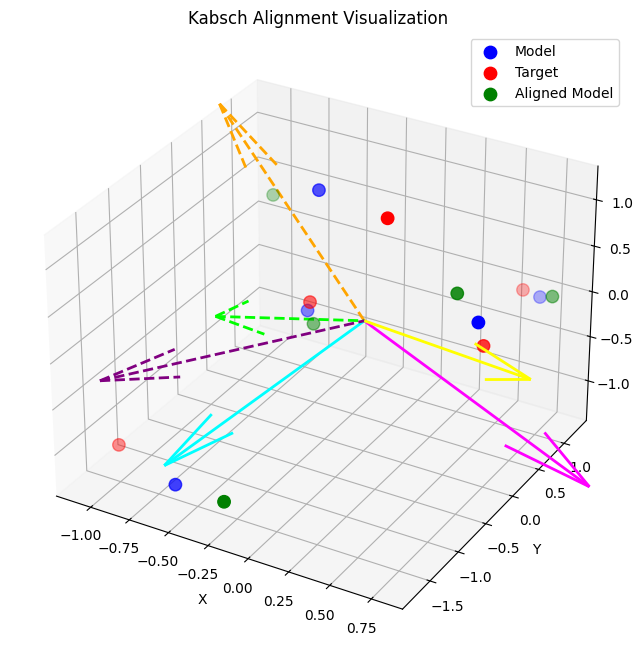

In [1]:
# %% [markdown]
# # Kabsch Alignment Visualization

# %%
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# -----------------------------
# Step 1: Generate example point clouds
# -----------------------------
np.random.seed(42)

# Create 5 random 3D points for model
model = np.random.randn(5, 3)

# Create a random rotation for target
theta = np.pi / 6  # 30 degrees
axis = np.array([0.5, 1.0, 0.2])
axis = axis / np.linalg.norm(axis)
K = np.array([[0, -axis[2], axis[1]],
              [axis[2], 0, -axis[0]],
              [-axis[1], axis[0], 0]])
R_true = np.eye(3) + np.sin(theta)*K + (1 - np.cos(theta))*(K@K)

# Target = rotated model
target = model @ R_true.T

# Center both clouds
model_centered = model - model.mean(axis=0)
target_centered = target - target.mean(axis=0)

# -----------------------------
# Step 2: Compute covariance and SVD
# -----------------------------
H = model_centered.T @ target_centered
U, S, Vt = np.linalg.svd(H)

# Compute optimal rotation
R = Vt.T @ U.T
# Ensure proper rotation
if np.linalg.det(R) < 0:
    Vt[-1, :] *= -1
    R = Vt.T @ U.T

aligned_model = model_centered @ R

# -----------------------------
# Step 3: Visualization function
# -----------------------------
def plot_clouds(model, target, aligned=None, axes=True):
    fig = plt.figure(figsize=(10,8))
    ax = fig.add_subplot(111, projection='3d')
    
    ax.scatter(*model.T, color='blue', label='Model', s=80)
    ax.scatter(*target.T, color='red', label='Target', s=80)
    
    if aligned is not None:
        ax.scatter(*aligned.T, color='green', label='Aligned Model', s=80)
    
    if axes:
        # Draw principal axes
        origin = np.zeros(3)
        for vec, color in zip(U.T, ['cyan','magenta','yellow']):
            ax.quiver(*origin, *vec, length=2, color=color, linewidth=2)
        for vec, color in zip(Vt.T, ['orange','lime','purple']):
            ax.quiver(*origin, *vec, length=2, color=color, linewidth=2, linestyle='dashed')
    
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.legend()
    ax.set_title('Kabsch Alignment Visualization')
    plt.show()

# -----------------------------
# Step 4: Plot original and aligned clouds
# -----------------------------
plot_clouds(model_centered, target_centered, aligned_model)
